# Heart Attack Risk Classification

This project compares classification models for heart attack risk. I use KNN, logistic regression, and a decision tree to see which model best separates high-risk and low-risk patients using ROC AUC, confusion-matrix metrics, validation performance, and Cohen's Kappa.

## Overview

The goal is to identify a reliable classification model while also thinking about how the best metric changes depending on the clinical scenario. I compare the models first, then use the metrics to decide which model makes the most sense for different hospital use cases.

In [1]:
from sklearn.linear_model import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import *
from sklearn.preprocessing import *
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score

In [2]:
ha = pd.read_csv("heart_attack.csv")
ha.drop_duplicates()
ha.describe()

,age,sex,cp,trtbps,chol,restecg,thalach,output
count,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,54.347985,0.673993,0.974359,132.098901,246.860806,0.538462,149.446886,0.534799
std,9.163134,0.469611,1.030456,17.700358,52.569726,0.528059,23.240707,0.499704
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,211.000000,0.000000,133.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.000000,1.000000,152.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.000000,1.000000,166.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,2.000000,202.000000,1.000000


## I Compared KNN, Logistic Regression, and a Decision Tree With Cross-Validation

I split the data into features and the outcome, then compared the models with cross-validation.

In [3]:
X = ha.drop(columns=["output"])
y = ha["output"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

## KNN Reaches 0.814 Cross-Validated ROC AUC

I used KNN first because it classifies patients based on nearby observations. Since KNN depends on distance, I scaled the features before fitting the model.

In [4]:
knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

fitted = knn_pipeline.fit(X_train, y_train)

knn_prob = fitted.predict_proba(X_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, knn_prob)

auc_cv_knn = cross_val_score(knn_pipeline, X, y, cv=5, scoring='roc_auc').mean()

y_pred_knn = knn_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)

print(f"Test ROC AUC of KNN Model: {roc_auc_test:.3f}")
print(f"Mean Cross-Validated ROC AUC: {auc_cv_knn:.3f}")
print("Confusion Matrix:")
pd.DataFrame(cm)

Test ROC AUC of KNN Model: 0.800
Mean Cross-Validated ROC AUC: 0.814
Confusion Matrix:


,0,1
0,22,12
1,8,27


## Logistic Regression Has the Highest Cross-Validated ROC AUC at 0.854

I used logistic regression because it performs well for binary classification and its coefficients show how each feature relates to predicted risk.

In [5]:
log_reg = LogisticRegression(max_iter=1000)
fitted = log_reg.fit(X_train, y_train)

log_prob = fitted.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, log_prob)
auc_log = auc(fpr, tpr)

auc_cv_log = cross_val_score(log_reg, X, y, cv=5, scoring='roc_auc').mean()

log_pred = fitted.predict(X_test)
cm = confusion_matrix(y_test, log_pred)

print(f"Test ROC AUC of Logistic Regression: {auc_log:.3f}")
print(f"Mean Cross-Validated ROC AUC: {auc_cv_log:.3f}")
print("\nConfusion Matrix:")
pd.DataFrame(cm)

Test ROC AUC of Logistic Regression: 0.855
Mean Cross-Validated ROC AUC: 0.854

Confusion Matrix:


,0,1
0,25,9
1,5,30


In [6]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': fitted.coef_[0]})
print("Logistic Regression Coefficients:")
coef_df

Logistic Regression Coefficients:


,Feature,Coefficient
0,age,0.004034
1,sex,-1.739713
2,cp,0.768300
3,trtbps,-0.020238
4,chol,-0.005464
5,restecg,0.378011
6,thalach,0.041015


## Decision Tree Has the Lowest Cross-Validated ROC AUC at 0.772

I included a decision tree to give readable threshold-based rules, but I kept it shallow to limit overfitting.

In [7]:
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
fitted = dt.fit(X_train, y_train)

dt_prob = fitted.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, dt_prob)
auc_dt = auc(fpr, tpr)

auc_cv_dt = cross_val_score(dt, X, y, cv=5, scoring='roc_auc').mean()

dt_pred = fitted.predict(X_test)
cm = confusion_matrix(y_test, dt_pred)

print(f"Test ROC AUC of Decision Tree: {auc_dt:.3f}")
print(f"Mean Cross-Validated ROC AUC: {auc_cv_dt:.3f}")
print("\nConfusion Matrix:")
pd.DataFrame(cm)

Test ROC AUC of Decision Tree: 0.772


Mean Cross-Validated ROC AUC: 0.772

Confusion Matrix:


,0,1
0,26,8
1,12,23


## Logistic Regression Has the Strongest Overall ROC AUC

Logistic regression performs best overall based on ROC AUC. It has the highest test ROC AUC at 0.855 and the highest mean cross-validated ROC AUC at 0.854, compared with 0.800 and 0.814 for KNN and 0.772 and 0.772 for the decision tree. 

The largest coefficient magnitudes are for sex, chest pain type, resting ECG results, maximum heart rate, resting blood pressure, cholesterol, and age. The sign of each coefficient indicates whether the feature is associated with higher or lower predicted risk after accounting for the other features.

In [8]:
roc_summary = pd.DataFrame({'Model': ['KNN', 'Logistic Regression', 'Decision Tree'], 'Test ROC AUC': [roc_auc_test, auc_log, auc_dt], 'Cross-Validated ROC AUC': [auc_cv_knn, auc_cv_log, auc_cv_dt]})

## The ROC Curve Shows Logistic Regression Separates Risk Groups Best

I used ROC curves to compare how well each model separates high-risk and low-risk patients across thresholds. Logistic regression has the strongest ROC AUC, so it separates the two groups best overall.

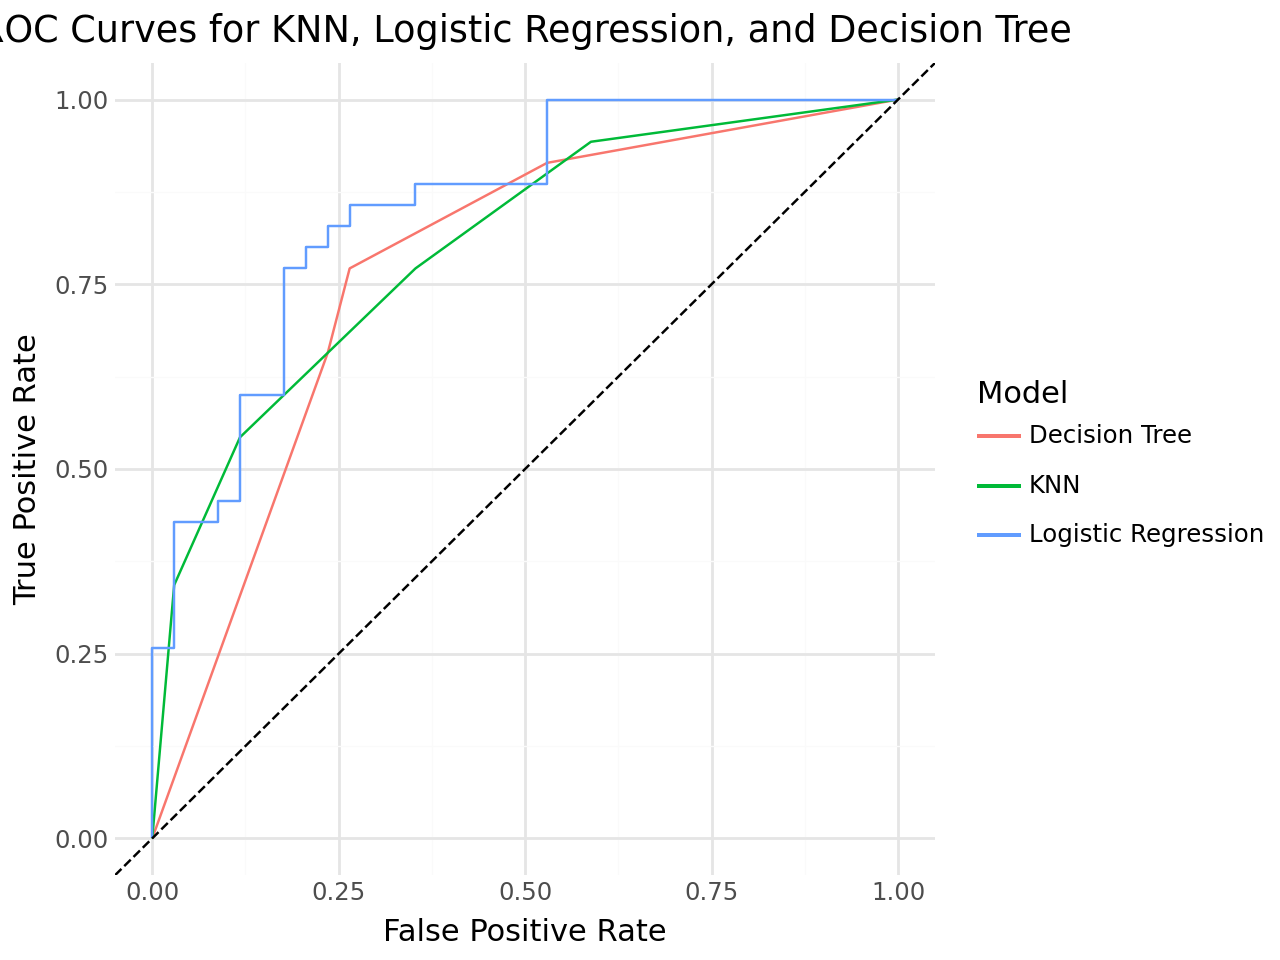

In [9]:
import numpy as np
from plotnine import *

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

roc_df = pd.DataFrame({'FPR': np.concatenate([fpr_knn, fpr_log, fpr_dt]), 'TPR': np.concatenate([tpr_knn, tpr_log, tpr_dt]), 'Model': ['KNN']*len(fpr_knn) + ['Logistic Regression']*len(fpr_log) + ['Decision Tree']*len(fpr_dt)})

ggplot(roc_df, aes(x='FPR', y='TPR', color='Model')) + geom_line() + geom_abline(linetype='dashed') + labs(title='ROC Curves for KNN, Logistic Regression, and Decision Tree', x='False Positive Rate', y='True Positive Rate') + theme_minimal()

## Logistic Regression Leads Accuracy, Recall, ROC AUC, and F1 Score

After comparing ROC AUC, I calculated sensitivity, precision, and F1 score. Logistic regression has the best overall metric profile, while KNN and the decision tree are useful comparisons.

### KNN Captures Some High-Risk Cases but Is Not the Strongest Model

In [10]:
knn_acc = cross_val_score(knn_pipeline, X, y, cv=5, scoring='accuracy').mean()
knn_prec = cross_val_score(knn_pipeline, X, y, cv=5, scoring='precision').mean()  
knn_rec = cross_val_score(knn_pipeline, X, y, cv=5, scoring='recall').mean()
knn_spec = cross_val_score(knn_pipeline, X, y, cv=5, scoring='roc_auc').mean() 
knn_f1 = cross_val_score(knn_pipeline, X, y, cv=5, scoring='f1').mean()

knn_results = pd.DataFrame({'Model': ['KNN Model'], 'Accuracy': [knn_acc], 'Precision (PPV)': [knn_prec], 'Recall (Sensitivity)': [knn_rec], 'Specificity': [knn_spec], 'F1 Score': [knn_f1]})

knn_results

,Model,Accuracy,Precision (PPV),Recall (Sensitivity),Specificity,F1 Score
0,KNN Model,0.717912,0.721558,0.781149,0.814109,0.748209


KNN captures a reasonable share of high-risk cases, with recall of 0.781 and precision of 0.722. Its accuracy is 0.718, F1 score is 0.748, and ROC AUC is 0.814. I use it as a benchmark, but I would not choose it as the final model because it is less interpretable than logistic regression.

### Logistic Regression Has the Best Overall Metric Balance

In [11]:
log_acc = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy').mean()
log_prec = cross_val_score(log_reg, X, y, cv=5, scoring='precision').mean()
log_rec = cross_val_score(log_reg, X, y, cv=5, scoring='recall').mean()
log_spec = cross_val_score(log_reg, X, y, cv=5, scoring='roc_auc').mean()
log_f1 = cross_val_score(log_reg, X, y, cv=5, scoring='f1').mean()

log_results = pd.DataFrame({'Model': ['Logistic Regression'], 'Accuracy': [log_acc], 'Precision (PPV)': [log_prec], 'Recall (Sensitivity)': [log_rec], 'Specificity': [log_spec], 'F1 Score': [log_f1]})

log_results

,Model,Accuracy,Precision (PPV),Recall (Sensitivity),Specificity,F1 Score
0,Logistic Regression,0.772727,0.777814,0.815172,0.854092,0.792724


Logistic regression provides the best overall balance in this analysis. It has the highest accuracy at 0.773, precision at 0.778, recall at 0.815, ROC AUC at 0.854, and F1 score at 0.793. I prefer it because it performs well across the main classification metrics while still allowing coefficient-based interpretation.

### Decision Tree Is Interpretable but Weaker Overall

In [12]:
dt_acc = cross_val_score(dt, X, y, cv=5, scoring='accuracy').mean()
dt_prec = cross_val_score(dt, X, y, cv=5, scoring='precision').mean()
dt_rec = cross_val_score(dt, X, y, cv=5, scoring='recall').mean()
dt_spec = cross_val_score(dt, X, y, cv=5, scoring='roc_auc').mean()
dt_f1 = cross_val_score(dt, X, y, cv=5, scoring='f1').mean()

dt_results = pd.DataFrame({'Model': ['Decision Tree'], 'Accuracy': [dt_acc], 'Precision (PPV)': [dt_prec], 'Recall (Sensitivity)': [dt_rec], 'Specificity': [dt_spec], 'F1 Score': [dt_f1]})

dt_results

,Model,Accuracy,Precision (PPV),Recall (Sensitivity),Specificity,F1 Score
0,Decision Tree,0.747138,0.7619,0.766667,0.772063,0.763789


The decision tree is easy to interpret, but its metrics are generally weaker than logistic regression. It has accuracy of 0.747, precision of 0.762, recall of 0.767, ROC AUC of 0.772, and F1 score of 0.764. I would use it mainly as an explanatory comparison rather than the primary prediction model.

In [13]:
results_df = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Decision Tree'],
    'Accuracy': [knn_acc, log_acc, dt_acc],
    'Precision (PPV)': [knn_prec, log_prec, dt_prec],
    'True Positive Rate / Recall / Sensitivity': [knn_rec, log_rec, dt_rec],
    'True Negative Rate / Specificity / Negative Predictive Value': [knn_spec, log_spec, dt_spec],
    'F1 Score': [knn_f1, log_f1, dt_f1]
})

print("Metrics of all Three Models (KNN, Logistic, & Decision Tree):")
results_df

Metrics of all Three Models (KNN, Logistic, & Decision Tree):


,Model,Accuracy,Precision (PPV),True Positive Rate / Recall / Sensitivity,True Negative Rate / Specificity / Negative Predictive Value,F1 Score
0,KNN,0.717912,0.721558,0.781149,0.814109,0.748209
1,Logistic Regression,0.772727,0.777814,0.815172,0.854092,0.792724
2,Decision Tree,0.747138,0.761900,0.766667,0.772063,0.763789


## Metric Selection Changes by Hospital Use Case

For the hospital use cases, I choose the evaluation metric based on the real consequence of each type of error. For each scenario, I state the metric I would use, the model I would recommend, and the score I would expect from the current results.

### Sensitivity Matters Most When Missed High-Risk Patients Create Legal Risk

If the hospital faces lawsuits after labeling a truly high-risk patient as low risk, I would prioritize sensitivity. False negatives are the most costly error in this setting because they represent high-risk patients the model misses. I would recommend logistic regression because it has the highest recall at 0.815, so I would expect it to identify about 81.5% of truly high-risk patients.

### Precision Matters Most When Bed Space Is Limited

If the hospital is overfull and only wants to monitor patients most likely to be high risk, I would prioritize precision. False positives are the most costly error here because they use bed space on patients who are not actually high risk. I would recommend logistic regression because it has the strongest precision among the compared models at 0.778, so I would expect about 77.8% of its high-risk predictions to be truly high risk.

### Interpretable Features Matter Most When Studying Heart Attack Risk Factors

If the hospital is studying root causes of heart attacks, I would choose logistic regression because it combines strong classification performance with interpretable coefficients. It has the highest accuracy at 0.773 and the highest ROC AUC at 0.854, so I would expect it to correctly classify about 77.3% of future observations. More importantly, the coefficient table shows the direction and relative strength of each feature's association with heart attack risk.

### F1 Score Matters Most When Comparing Model Predictions to Doctor Diagnoses

If the hospital is training new doctors and comparing their diagnoses to the algorithm, I would use F1 score because it balances precision and recall in one metric. Logistic regression remains the best recommendation because it has the highest F1 score at 0.793, along with the strongest precision and recall balance. I would expect an F1 score of about 0.79 when using this model as the comparison point for future diagnoses.

In [14]:
ha_validation = pd.read_csv("heart_attack_validation.csv")

ha_validation.drop_duplicates()

ha_validation.describe()

y_validation = ha_validation['output']
X_validation = ha_validation.drop(columns=['output'])

## KNN Correctly Identifies 15 High-Risk Validation Patients and Misses 4

In [15]:
knn_target = knn_pipeline.predict(X_validation)
knn_prob = knn_pipeline.predict_proba(X_validation)[:, 1]
knn_cm = confusion_matrix(y_validation, knn_target)
knn_auc = roc_auc_score(y_validation, knn_prob)
knn_prec = precision_score(y_validation, knn_target)
knn_rec = recall_score(y_validation, knn_target)

knn_cm_df = pd.DataFrame(knn_cm)

print("Confusion Matrix:")
knn_cm_df

Confusion Matrix:


,0,1
0,8,3
1,4,15


## Logistic Regression Keeps 15 True Positives With Fewer False Positives

In [16]:
log_pred = log_reg.predict(X_validation)
log_prob = log_reg.predict_proba(X_validation)[:, 1]
log_cm = confusion_matrix(y_validation, log_pred)
log_auc = roc_auc_score(y_validation, log_prob)
log_prec = precision_score(y_validation, log_pred)
log_rec = recall_score(y_validation, log_pred)

print("Confusion Matrix:")
log_cm_df = pd.DataFrame(log_cm)
log_cm_df

Confusion Matrix:


,0,1
0,9,2
1,4,15


## Decision Tree Misses 7 High-Risk Patients on Validation Data

In [17]:
dt_pred = dt.predict(X_validation)
dt_prob = dt.predict_proba(X_validation)[:, 1]
dt_cm = confusion_matrix(y_validation, dt_pred)
dt_auc = roc_auc_score(y_validation, dt_prob)
dt_prec = precision_score(y_validation, dt_pred)
dt_rec = recall_score(y_validation, dt_pred)

print("Confusion Matrix:")
dt_cm_df = pd.DataFrame(dt_cm)
dt_cm_df

Confusion Matrix:


,0,1
0,10,1
1,7,12


In [18]:
confusion_matrix = pd.concat([knn_cm_df, log_cm_df, dt_cm_df], ignore_index=True)
confusion_matrix

knn_cm_df = pd.DataFrame(knn_cm, columns=['Pred 0', 'Pred 1'])
knn_cm_df['Model'] = 'KNN'

log_cm_df = pd.DataFrame(log_cm, columns=['Pred 0', 'Pred 1'])
log_cm_df['Model'] = 'Logistic Regression'

dt_cm_df = pd.DataFrame(dt_cm, columns=['Pred 0', 'Pred 1'])
dt_cm_df['Model'] = 'Decision Tree'

confusion_matrices = pd.concat([knn_cm_df, log_cm_df, dt_cm_df], ignore_index=True)

print("Confusion Matrix for all Three Models:")
confusion_matrices

Confusion Matrix for all Three Models:


,Pred 0,Pred 1,Model
0,8,3,KNN
1,4,15,KNN
2,9,2,Logistic Regression
3,4,15,Logistic Regression
4,10,1,Decision Tree
5,7,12,Decision Tree


In [19]:
metrics_df = pd.DataFrame({'Model': ['KNN', 'Logistic Regression', 'Decision Tree'], 'ROC AUC': [knn_spec, log_spec, dt_spec], 'Precision': [knn_prec, log_prec, dt_prec], 'Recall': [knn_rec, log_rec, dt_rec]})

print("Comparing Model Metrics (ROC AUC, Precision, Recall):")
metrics_df

Comparing Model Metrics (ROC AUC, Precision, Recall):


,Model,ROC AUC,Precision,Recall
0,KNN,0.814109,0.833333,0.789474
1,Logistic Regression,0.854092,0.882353,0.789474
2,Decision Tree,0.772063,0.923077,0.631579


## Validation Results Still Support Logistic Regression

The validation results are consistent with the cross-validated estimates. KNN has validation ROC AUC of 0.814, precision of 0.833, and recall of 0.789. Logistic regression has validation ROC AUC of 0.854, precision of 0.882, and recall of 0.789. The decision tree has validation ROC AUC of 0.772, precision of 0.923, and recall of 0.632.

Logistic regression remains the strongest practical choice because it keeps the highest ROC AUC at 0.854, has strong validation precision at 0.882, and matches KNN's validation recall at 0.789.

## Cohen's Kappa Confirms the Same Model Choice

In [20]:
from sklearn.metrics import cohen_kappa_score

kappa_knn = cohen_kappa_score(y_validation, knn_target)
kappa_log = cohen_kappa_score(y_validation, log_pred)
kappa_dt = cohen_kappa_score(y_validation, dt_pred)
kappa_df = pd.DataFrame({'Model': ['KNN', 'Logistic Regression', 'Decision Tree'],"Cohen's Kappa": [kappa_knn, kappa_log, kappa_dt]})

kappa_df

,Model,Cohen's Kappa
0,KNN,0.507042
1,Logistic Regression,0.585253
2,Decision Tree,0.484979


I used Cohen's Kappa because it accounts for agreement that could happen by chance, which is useful when class balance is a concern.

The Kappa values are lower than the raw classification metrics, which is expected because Kappa is stricter. Logistic regression has the highest Cohen's Kappa at 0.585, compared with 0.507 for KNN and 0.485 for the decision tree. This does not materially change the recommendation: logistic regression remains the most useful model overall because it combines strong predictive performance with interpretability.